In [1]:
import numpy as np
from scipy.stats import rankdata, norm, ks_2samp
from statsmodels.distributions.copula.api import GaussianCopula
import matplotlib.pyplot as plt

In [2]:
data = {
    1: {
        "agv": np.array([2.24, 2.96, 2.45]),
        "op":  np.array([10.33, 9.36, 9.18])
    },
    2: {
        "agv": np.array([5.32, 4.21, 4.68]),
        "op":  np.array([19.15, 16.04, 19.48])
    },
    3: {
        "agv": np.array([7.37, 7.52, 8.28]),
        "op":  np.array([21.10, 26.31, 28.39])
    },
    4: {
        "agv": np.array([10.98, 10.51, 10.53]),
        "op":  np.array([34.25, 36.48, 25.71])
    }
}

In [3]:
# 1 dataset of all opservations
agv_all = np.concatenate([data[i]["agv"] for i in data])
op_all  = np.concatenate([data[i]["op"] for i in data])

# rank transform → uniform [0,1]
u_agv = rankdata(agv_all) / (len(agv_all) + 1)
u_op  = rankdata(op_all) / (len(op_all) + 1)

data_uniform = np.column_stack([u_agv, u_op])

# fit copula
copula = GaussianCopula(k_dim=2)
copula.fit_corr_param(data_uniform)

np.float64(0.9450008187146683)

In [4]:
#extrapolate to more items
items = np.array([1,2,3,4])

agv_means = np.array([np.mean(data[i]["agv"]) for i in items])
op_means  = np.array([np.mean(data[i]["op"]) for i in items])

# lineaire fit
agv_coef = np.polyfit(items, agv_means, 1)
op_coef  = np.polyfit(items, op_means, 1)

def extrapolate_mean(n, coef):
    return coef[0]*n + coef[1]

In [5]:
# optain information about data
def get_stats(n_items):
    agv = data[n_items]["agv"]
    op = data[n_items]["op"]
    
    return {
        "agv_mu": np.mean(agv),
        "agv_sigma": np.std(agv, ddof=1),
        "op_mu": np.mean(op),
        "op_sigma": np.std(op, ddof=1)
    }

In [6]:
def sample_service_time(n_items):
    
    # 1. sample uit copula
    samples = copula.rvs(1)
    samples = np.atleast_2d(samples)
    u1, u2 = samples[0]
    
    # 2. determine mean + std 
    if n_items in data:
        stats = get_stats(n_items)
        agv_mu = stats["agv_mu"]
        agv_sigma = stats["agv_sigma"]
        op_mu = stats["op_mu"]
        op_sigma = stats["op_sigma"]
        
    else:
        agv_mu = extrapolate_mean(n_items, agv_coef)
        op_mu  = extrapolate_mean(n_items, op_coef)
        
        agv_sigma = 0.1 * agv_mu
        op_sigma  = 0.1 * op_mu
    
    # 3. transform copula → real time
    agv_time = norm.ppf(u1, loc=agv_mu, scale=agv_sigma)
    op_time  = norm.ppf(u2, loc=op_mu, scale=op_sigma)
    
    # 4. lower limit, can be turned off
    agv_time = max(agv_time, 1.0)
    op_time  = max(op_time, 5.0)
    
    return agv_time, op_time

In [7]:
for n in [1,2,3,4,5,6,7,8]:
    agv, op = sample_service_time(n)
    print(f"{n} items -> AGV: {agv:.2f}s, Operator: {op:.2f}s")

1 items -> AGV: 3.21s, Operator: 8.90s
2 items -> AGV: 4.84s, Operator: 13.95s
3 items -> AGV: 7.18s, Operator: 28.80s
4 items -> AGV: 10.55s, Operator: 32.64s
5 items -> AGV: 11.97s, Operator: 41.64s
6 items -> AGV: 17.57s, Operator: 42.28s
7 items -> AGV: 19.43s, Operator: 48.26s
8 items -> AGV: 24.92s, Operator: 58.49s


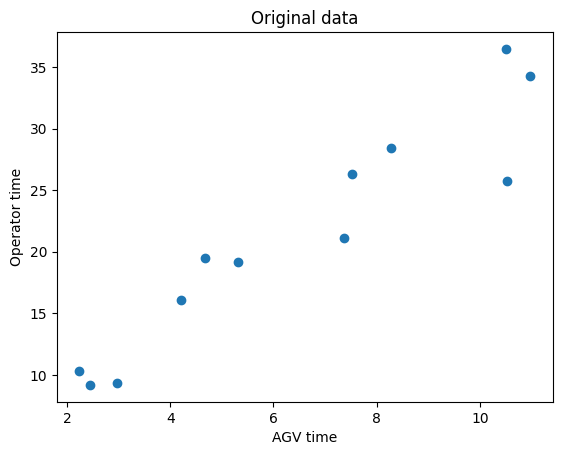

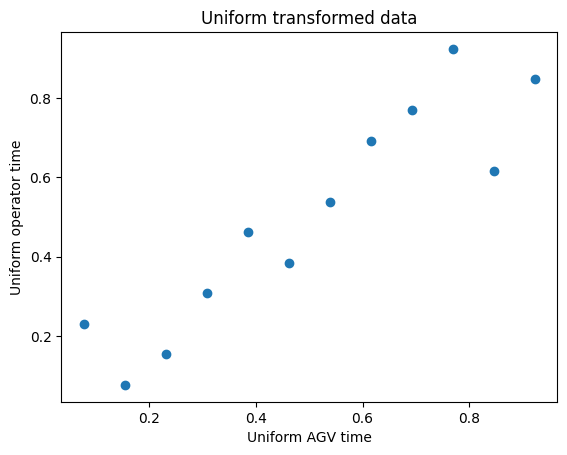

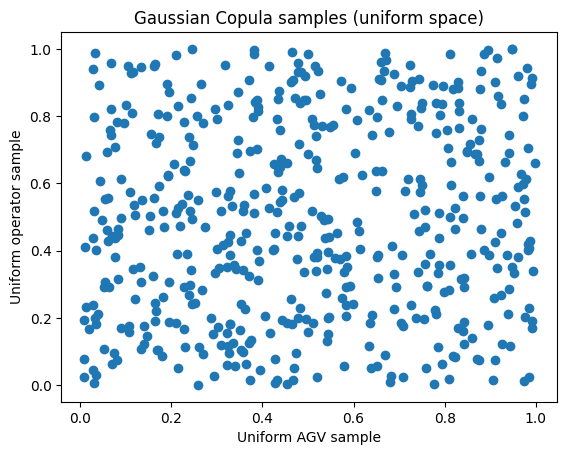

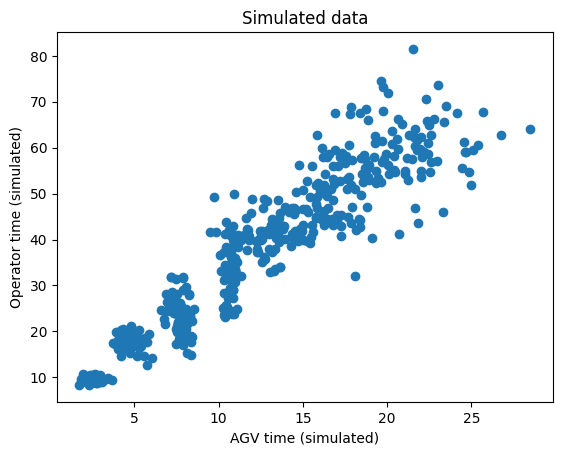

In [14]:
# originele data
plt.figure()
plt.scatter(agv_all, op_all)
plt.xlabel("AGV time")
plt.ylabel("Operator time")
plt.title("Original data")
plt.savefig('GC Original data.png')
plt.show()

# uniforme data (rank transform)
plt.figure()
plt.scatter(u_agv, u_op)
plt.xlabel("Uniform AGV time")
plt.ylabel("Uniform operator time")
plt.title("Uniform transformed data")
plt.savefig('GC Uniform transformed data.png')
plt.show()

# copula samples (uniform)
samples = copula.rvs(500)
samples = np.atleast_2d(samples)

plt.figure()
plt.scatter(samples[:,0], samples[:,1])
plt.xlabel("Uniform AGV sample")
plt.ylabel("Uniform operator sample")
plt.title("Gaussian Copula samples (uniform space)")
plt.savefig('GC Gaussian Copula samples.png')
plt.show()

# terug naar echte tijden
agv_sim = []
op_sim = []

for _ in range(500):
    a, o = sample_service_time(np.random.choice([1,2,3,4,5,6,7,8]))
    agv_sim.append(a)
    op_sim.append(o)

plt.figure()
plt.scatter(agv_sim, op_sim)
plt.xlabel("AGV time (simulated)")
plt.ylabel("Operator time (simulated)")
plt.title("Simulated data")
plt.savefig('GC Simulated data.png')
plt.show()

In [15]:
from scipy.stats import ks_2samp

print(f"{'Items':<6} | {'AGV D':<8} | {'AGV p':<8} | {'OP D':<8} | {'OP p':<8}")
print("-"*50)

for n in [1,2,3,4]:
    
    agv_real = data[n]["agv"]
    op_real  = data[n]["op"]
    
    agv_sim = []
    op_sim = []
    
    for _ in range(500):
        a, o = sample_service_time(n)
        agv_sim.append(a)
        op_sim.append(o)
    
    ks_agv = ks_2samp(agv_real, agv_sim)
    ks_op  = ks_2samp(op_real, op_sim)
    
    print(f"{n:<6} | {ks_agv.statistic:<8.3f} | {ks_agv.pvalue:<8.3f} | {ks_op.statistic:<8.3f} | {ks_op.pvalue:<8.3f}")

Items  | AGV D    | AGV p    | OP D     | OP p    
--------------------------------------------------
1      | 0.265    | 0.956    | 0.315    | 0.847   
2      | 0.190    | 0.999    | 0.387    | 0.634   
3      | 0.323    | 0.821    | 0.303    | 0.882   
4      | 0.377    | 0.662    | 0.317    | 0.841   


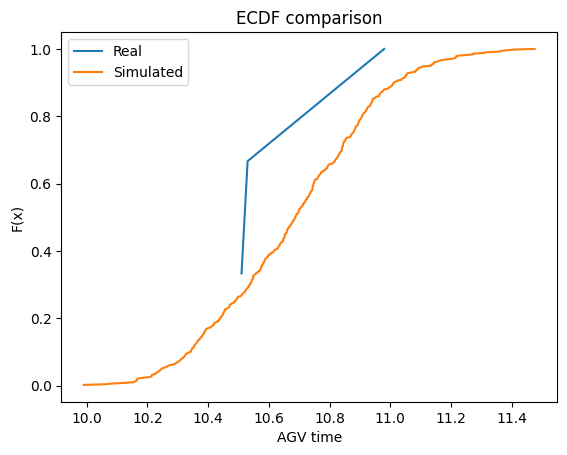

In [21]:
def plot_ecdf(data, label):
    x = np.sort(data)
    y = np.arange(1, len(x)+1) / len(x)
    plt.plot(x, y, label=label)

plt.figure()

plot_ecdf(agv_real, "Real")
plot_ecdf(agv_sim, "Simulated")

plt.legend()
plt.title("ECDF comparison")
plt.xlabel("AGV time")
plt.ylabel("F(x)")
plt.savefig('KS-test AGV.png')
plt.show()

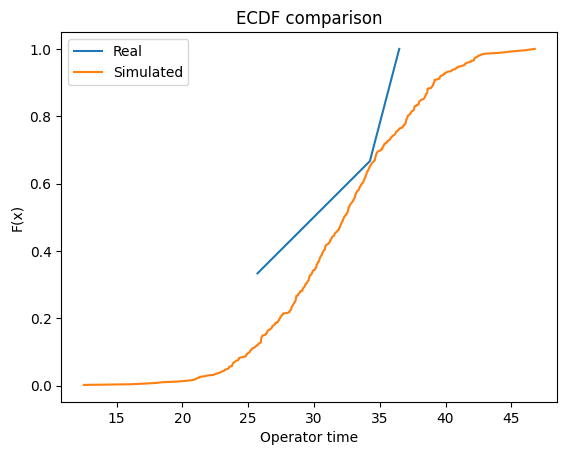

In [19]:
def plot_ecdf(data, label):
    x = np.sort(data)
    y = np.arange(1, len(x)+1) / len(x)
    plt.plot(x, y, label=label)

plt.figure()

plot_ecdf(op_real, "Real")
plot_ecdf(op_sim, "Simulated")

plt.legend()
plt.title("ECDF comparison")
plt.xlabel("Operator time")
plt.ylabel("F(x)")
plt.savefig('KS-test Operator.png')
plt.show()

In [11]:
def simulate_queue(n_orders, arrival_rate):
    
    arrivals = np.cumsum(np.random.exponential(1/arrival_rate, n_orders))
    
    operator_free_time = 0
    
    waiting_times = []
    agv_departure_times = []
    
    for i in range(n_orders):
        
        arrival = arrivals[i]
        
        # aantal items
        n_items = np.random.randint(1,5)
        
        # copula sample
        agv_time, op_time = sample_service_time(n_items)
        
        # wanneer kan proces starten?
        start_time = max(arrival, operator_free_time)
        
        # operator bepaalt queue!
        operator_finish = start_time + op_time
        
        # AGV vertrekt eerder
        agv_departure = start_time + agv_time
        
        # wachttijd = wachten op operator
        waiting = start_time - arrival
        
        # update
        operator_free_time = operator_finish
        
        # opslaan
        waiting_times.append(waiting)
        agv_departure_times.append(agv_departure)
    
    return {
        "avg_waiting_time": np.mean(waiting_times),
        "avg_agv_time_in_system": np.mean(np.array(agv_departure_times) - arrivals),
        "utilization_operator": operator_free_time / arrivals[-1]
    }

In [12]:
#arrival rate en hoeveelheid orders wordt bepaald door de agv (zelf aanpassen)

result = simulate_queue(n_orders=1000, arrival_rate=1)

print("Average waiting time:", result["avg_waiting_time"])
print("avg agv time in system:", result["avg_agv_time_in_system"])
print("utilization operator:", result["utilization_operator"])

Average waiting time: 10435.292868067154
avg agv time in system: 10441.845789279507
utilization operator: 22.046617513651682
